<div align="center">

# ASL

</div>

Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<div align="center" style="color: purple">

## **Download dataset**

</div>

In [9]:
!kaggle datasets download datamunge/sign-language-mnist

Dataset URL: https://www.kaggle.com/datasets/datamunge/sign-language-mnist
License(s): CC0-1.0
sign-language-mnist.zip: Skipping, found more recently modified local copy (use --force to force download)


In [10]:
# import kagglehub
# import os

# # Define the path for the dataset
# dataset_path = "."
# dataset_zip_name = "sign-language-mnist.zip"
# dataset_zip_path = os.path.join(dataset_path, dataset_zip_name)

# print(f"Current working directory: {os.getcwd()}")

# # Check if the dataset zip file already exists
# if os.path.exists(dataset_zip_path):
#     print(f"Dataset '{dataset_zip_name}' already downloaded in the current directory.")
#     path = dataset_zip_path
# else:
#     print("Downloading dataset...")
#     # Download latest version to the current directory
#     path = kagglehub.dataset_download(
#         "datamunge/sign-language-mnist",
#         path=dataset_path
#     )
#     print("Dataset downloaded successfully.")

# print("Path to dataset files:", path)

## Getting the data

In [11]:
import zipfile

with zipfile.ZipFile("sign-language-mnist.zip", 'r') as zip_ref:
    zip_ref.extractall("data/asl_mnist")

In [13]:
import pandas as pd

train_path = "data/asl_mnist/sign_mnist_train.csv"
test_path = "data/asl_mnist/sign_mnist_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (27455, 785)
Test shape: (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


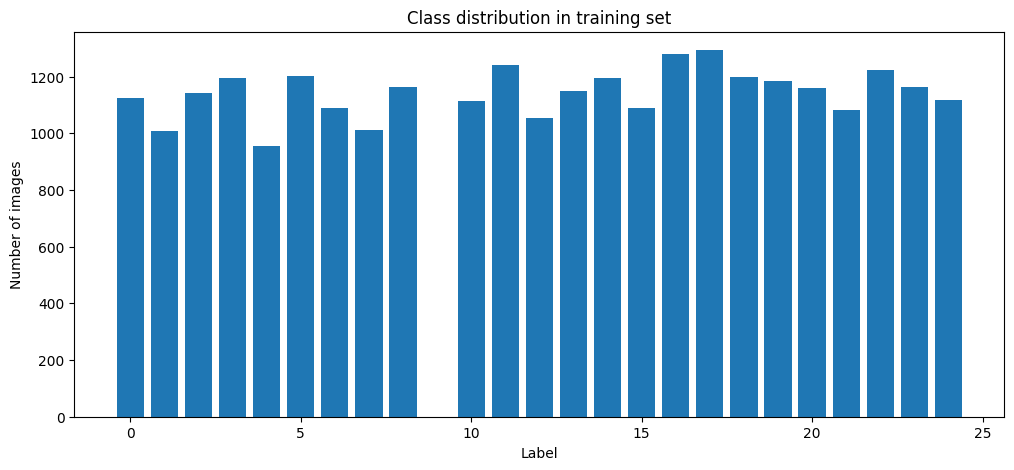

In [14]:
import matplotlib.pyplot as plt

label_counts = train_df["label"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(label_counts.index, label_counts.values)
plt.xlabel("Label")
plt.ylabel("Number of images")
plt.title("Class distribution in training set")
plt.show()

In [ ]:
#  

import pandas as pd
import torch
from torch.utils.data import Dataset

class SignLanguageMNIST(Dataset):
    def __init__(self, csv_file):
        data = pd.read_csv(csv_file)
        self.labels = data.iloc[:, 0].values
        self.images = data.iloc[:, 1:].values.reshape(-1, 28, 28)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx], dtype=torch.float32).unsqueeze(0) / 255.0
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

In [ ]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

